# **Libraries**

In [1]:
import numpy as np
import pandas as pd
import sklearn.metrics as skm
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor as rfs
from sklearn.neural_network import MLPRegressor 
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression 
from mlxtend.feature_selection import SequentialFeatureSelector as sfs
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RandomizedSearchCV
from mlxtend.plotting import plot_sequential_feature_selection as plot_sfs

from scipy.stats import uniform as sp_randFloat
from scipy.stats import randint as sp_randInt

def mape(Y_actual,Y_Predicted):
    mape = np.mean(np.abs((Y_actual - Y_Predicted)/Y_actual))*100
    return mape

In [2]:
data = pd.read_csv('tab_training.csv')
data_validation = pd.read_csv('tab_validation.csv')

data.head(), data_validation.head()

(   Unnamed: 0    lon   lat  year  month    prec       temp         etp
 0           1 -49.75 -18.5  1981      1  238.39  24.874516  122.962946
 1           2 -49.75 -18.5  1981      2   76.47  25.044643  114.768245
 2           3 -49.75 -18.5  1981      3  240.87  25.520323  130.011549
 3           4 -49.75 -18.5  1981      4   59.35  22.942333   86.990517
 4           5 -49.75 -18.5  1981      5    0.35  22.302903   78.978930,
    Unnamed: 0    lon   lat  year  month    prec       temp         etp
 0           1 -49.75 -18.5  2015      1  126.42  26.829032  154.050025
 1           2 -49.75 -18.5  2015      2  219.28  25.247857  113.652797
 2           3 -49.75 -18.5  2015      3  219.52  24.593871  110.835384
 3           4 -49.75 -18.5  2015      4   68.37  24.806333  105.644868
 4           5 -49.75 -18.5  2015      5   57.67  22.377742   72.644352)

# **Pre processing**

In [3]:
x1 = data[['lon','lat','year','month']]
x2 = data[['prec','temp']]
y = data['etp']

x1_vali= data_validation[['lon','lat','year','month']]
x2_validation = data_validation[['prec','temp']]
y_validation = data_validation['etp']

In [4]:
x2 = StandardScaler().fit_transform(x2)
x2 = pd.DataFrame(x2, columns=[data.columns[5:7]])
x2.head()

x2_validation = StandardScaler().fit_transform(x2_validation)
x2_validation = pd.DataFrame(x2_validation, columns=[data_validation.columns[5:7]])
x2_validation.head(),x2_validation.head()

(       prec      temp
 0  0.274788  1.222406
 1  1.268645  0.502715
 2  1.271213  0.205045
 3 -0.346506  0.301750
 4 -0.461025 -0.803653,
        prec      temp
 0  0.274788  1.222406
 1  1.268645  0.502715
 2  1.271213  0.205045
 3 -0.346506  0.301750
 4 -0.461025 -0.803653)

In [5]:
x = pd.concat([x1,x2],axis=1, join='inner')
x_validation = pd.concat([x1_vali,x2_validation],axis=1, join='inner')

x.head(),x_validation.head()

(     lon   lat  year  month   (prec,)   (temp,)
 0 -49.75 -18.5  1981      1  1.063434  0.792985
 1 -49.75 -18.5  1981      2 -0.406368  0.870504
 2 -49.75 -18.5  1981      3  1.085946  1.087250
 3 -49.75 -18.5  1981      4 -0.561772 -0.087425
 4 -49.75 -18.5  1981      5 -1.097335 -0.378785,
      lon   lat  year  month   (prec,)   (temp,)
 0 -49.75 -18.5  2015      1  0.274788  1.222406
 1 -49.75 -18.5  2015      2  1.268645  0.502715
 2 -49.75 -18.5  2015      3  1.271213  0.205045
 3 -49.75 -18.5  2015      4 -0.346506  0.301750
 4 -49.75 -18.5  2015      5 -0.461025 -0.803653)

In [6]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=.3, random_state=1)
x_train.to_csv('x_train.csv')
y_test.to_csv('y_test.csv')
y_train.to_csv('y_train.csv')
x_test.to_csv('x_test.csv')

# **Random Forest**

In [7]:
rf_model = rfs().fit(x_train, y_train)
             

## **Random Search param**

In [8]:
n_estimators = [int(x) for x in np.linspace(start = 50, stop = 1000, num = 50)]
# Number of features to consider at every split
max_features = [1,2,3]
# Maximum number of levels in tree
max_depth = [int(x) for x in np.linspace(1, 100, num = 5)]

hyperpar_space = {'max_depth':max_depth,
                  'n_estimators':n_estimators,
                  'max_features':max_features
                 }

rs_rf = RandomizedSearchCV(rf_model, param_distributions=hyperpar_space,
                        n_iter=20, scoring="r2", random_state=1,
                        n_jobs=-1, cv=10, return_train_score=True).fit(x_train, y_train)

In [9]:
hyperpar_space

{'max_depth': [1, 25, 50, 75, 100],
 'n_estimators': [50,
  69,
  88,
  108,
  127,
  146,
  166,
  185,
  205,
  224,
  243,
  263,
  282,
  302,
  321,
  340,
  360,
  379,
  398,
  418,
  437,
  457,
  476,
  495,
  515,
  534,
  554,
  573,
  592,
  612,
  631,
  651,
  670,
  689,
  709,
  728,
  747,
  767,
  786,
  806,
  825,
  844,
  864,
  883,
  903,
  922,
  941,
  961,
  980,
  1000],
 'max_features': [1, 2, 3]}

In [10]:
pd.DataFrame.from_dict(rs_rf.cv_results_).to_csv('random_Forest_iter.csv')
pd.DataFrame.from_dict(rs_rf.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_n_estimators,param_max_features,param_max_depth,params,split0_test_score,split1_test_score,...,split2_train_score,split3_train_score,split4_train_score,split5_train_score,split6_train_score,split7_train_score,split8_train_score,split9_train_score,mean_train_score,std_train_score
0,13.816575,0.554698,4.581673,2.442337,534,1,100,"{'n_estimators': 534, 'max_features': 1, 'max_...",0.992896,0.993713,...,0.998987,0.998947,0.999042,0.998971,0.998977,0.998978,0.999025,0.998989,0.998989,0.000029
1,9.906890,0.180459,0.318882,0.013651,398,1,50,"{'n_estimators': 398, 'max_features': 1, 'max_...",0.992915,0.993294,...,0.998934,0.998915,0.998969,0.999006,0.998978,0.998974,0.998953,0.998960,0.998961,0.000024
2,24.497822,2.029618,11.152151,6.868161,806,1,50,"{'n_estimators': 806, 'max_features': 1, 'max_...",0.992936,0.993659,...,0.999027,0.998999,0.998994,0.998981,0.998992,0.998978,0.999012,0.999011,0.998999,0.000016
3,44.010394,1.927618,5.718972,4.620927,980,3,75,"{'n_estimators': 980, 'max_features': 3, 'max_...",0.999057,0.998976,...,0.999848,0.999845,0.999848,0.999846,0.999845,0.999841,0.999859,0.999847,0.999848,0.000005
4,4.277177,0.086771,0.175235,0.003669,825,2,1,"{'n_estimators': 825, 'max_features': 2, 'max_...",0.563442,0.562345,...,0.564110,0.550155,0.551508,0.552593,0.565475,0.565758,0.559507,0.560522,0.557650,0.005814
5,11.707044,0.164595,0.300228,0.016260,360,2,100,"{'n_estimators': 360, 'max_features': 2, 'max_...",0.998318,0.998279,...,0.999723,0.999735,0.999732,0.999729,0.999733,0.999732,0.999742,0.999738,0.999731,0.000006
6,11.640285,0.192864,0.229973,0.016930,282,3,25,"{'n_estimators': 282, 'max_features': 3, 'max_...",0.999071,0.998965,...,0.999828,0.999837,0.999842,0.999842,0.999838,0.999843,0.999853,0.999841,0.999842,0.000006
7,3.457597,0.036894,0.147924,0.006419,709,2,1,"{'n_estimators': 709, 'max_features': 2, 'max_...",0.570350,0.552646,...,0.554792,0.555432,0.557143,0.558714,0.543112,0.550679,0.555018,0.573374,0.555256,0.008443
8,30.705231,0.704925,0.647632,0.068098,728,3,75,"{'n_estimators': 728, 'max_features': 3, 'max_...",0.999051,0.998977,...,0.999852,0.999846,0.999850,0.999847,0.999842,0.999842,0.999858,0.999845,0.999848,0.000004
9,3.519027,0.040252,0.149837,0.004606,728,2,1,"{'n_estimators': 728, 'max_features': 2, 'max_...",0.561667,0.560552,...,0.561494,0.553091,0.567946,0.570069,0.567035,0.560231,0.562011,0.569282,0.561429,0.006908


<AxesSubplot:>

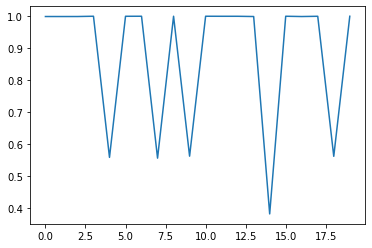

In [11]:
pd.DataFrame.from_dict(rs_rf.cv_results_)['mean_train_score'].plot()

In [12]:
print("Optimal hyperparameter combination:", rs_rf.best_params_)
print()
print("Mean cross-validated training accuracy score:",
      rs_rf.best_score_)
print()

Optimal hyperparameter combination: {'n_estimators': 379, 'max_features': 3, 'max_depth': 75}

Mean cross-validated training accuracy score: 0.99891000360419



### ***Feature Importance***

In [13]:
importance = rs_rf.best_estimator_.feature_importances_
importance_graf = pd.DataFrame({'lon':[importance[0]],'lat':[importance[1]],
                                     'year':[importance[2]],'month':[importance[3]],
                                     'prec':[importance[4]], 'temp':[importance[5]]
                                })
importance_graf

,lon,lat,year,month,prec,temp
0,0.008141,0.00588,0.005141,0.229773,0.094046,0.657019


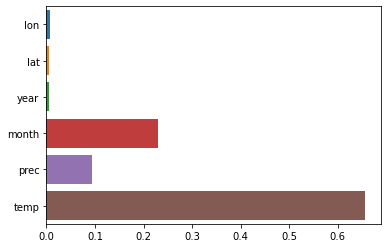

In [14]:
sns.barplot(data=importance_graf, orient='h');

## **Train**

In [15]:
yest_train = rs_rf.best_estimator_.predict(x_train)
pd.DataFrame.from_dict(yest_train).to_csv('random_Forest_train_est.csv')

In [16]:
datagraf = pd.DataFrame({'Yobs':y_train,
                         'Yest': yest_train})
datagraf.head()

,Yobs,Yest
2917,88.255314,88.710331
8447,105.929118,105.877557
6247,80.895431,80.932411
12051,80.069502,80.110312
17809,84.159994,84.507728


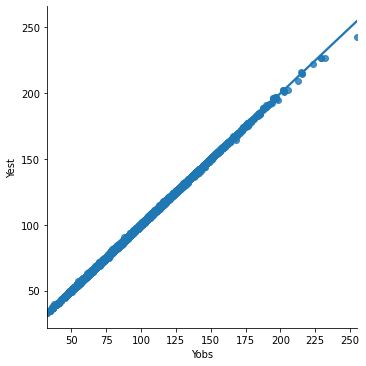

In [17]:
sns.lmplot(x='Yobs',y='Yest',data=datagraf);

In [18]:
r2 = skm.r2_score(y_train,yest_train)
mse=skm.mean_squared_error(y_train,yest_train)
rmse = mse**0.5
mae = skm.mean_absolute_error(y_train,yest_train)
rrmse = rmse*100/np.mean(y_train)
rf_mape = mape(y_train,yest_train)

r2,rmse,rrmse,rf_mape

(0.999867686531759,
 0.3108693683636469,
 0.3183489155507185,
 0.19073723615661548)

findfont: Font family ['Segoe UI Bold'] not found. Falling back to DejaVu Sans.
findfont: Font family ['Segoe UI Bold'] not found. Falling back to DejaVu Sans.


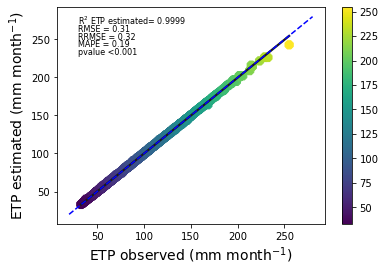

In [19]:
x=[20,280]
y=x

points = plt.scatter(y='Yest', x='Yobs',data=datagraf,
                     c=datagraf["Yobs"],marker="8", s=80, cmap="viridis") 
cbar = plt.colorbar(points, shrink=1)

sns.regplot(y='Yest', x='Yobs', data=datagraf, scatter=False, color=".1")

plt.plot(x,y, 'b--',data=None)

pvalue = 0.001
plt.text(30, 270, 'R$\mathregular{^{2}}$ ETP estimated= %0.4f' % r2,family='Segoe UI Bold',fontsize=8, color= 'black')
plt.text(30,260, 'RMSE = %0.2f'% rmse,family='Segoe UI Bold',fontsize=8)
plt.text(30,250, 'RRMSE = %0.2f'% rrmse,family='Segoe UI Bold',fontsize=8)
plt.text(30,240, 'MAPE = %0.2f'% rf_mape,family='Segoe UI Bold',fontsize=8)
plt.text(30, 230,'pvalue <%0.3f' % pvalue,family='Segoe UI Bold',fontsize=8)
plt.xlabel('ETP observed (mm month$\mathregular{^{-1}}$)',fontsize=14, family='Segoe UI Bold')
plt.ylabel('ETP estimated (mm month$\mathregular{^{-1}}$)',fontsize=14, family='Segoe UI Bold')
plt.rcParams['figure.figsize'] = (4,6)

#plt.savefig('.png', transparent = False,bbox_inches='tight', dpi=1000)

## **Test**

In [20]:
yest_test = rs_rf.best_estimator_.predict(x_test)
pd.DataFrame.from_dict(yest_test).to_csv('random_Forest_test_est.csv')

In [21]:
data = pd.DataFrame({'Yobs':y_test,
                         'Yest_rf': yest_test})

In [22]:
datagraf = pd.DataFrame({'Yobs':y_test,
                         'Yest': yest_test})
datagraf.head()

,Yobs,Yest
15923,103.036736,101.959194
16236,103.541886,102.054054
3645,155.410013,155.885424
13405,100.205722,100.464181
2853,185.456329,184.495143


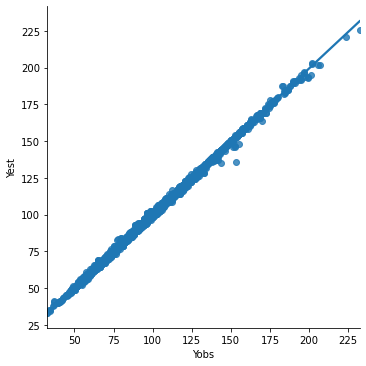

In [23]:
sns.lmplot(x='Yobs',y='Yest',data=datagraf);

In [24]:
r2 = skm.r2_score(y_test,yest_test)
mse=skm.mean_squared_error(y_test,yest_test)
rmse = mse**0.5
rrmse = rmse*100/np.mean(y_test)
rf_mape = mape(y_test,yest_test)

r2,rmse,rrmse,rf_mape

(0.9990848797616022, 0.8257988912496967, 0.8391073544619366, 0.508322000518015)

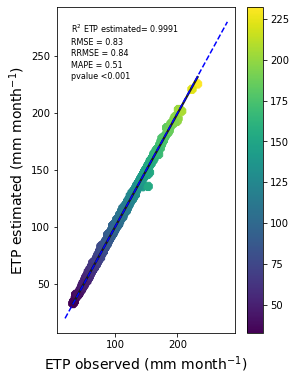

In [25]:
x=[20,280]
y=x

points = plt.scatter(y='Yest', x='Yobs',data=datagraf,
                     c=datagraf["Yobs"],marker="8", s=80, cmap="viridis") 
cbar = plt.colorbar(points, shrink=1)

sns.regplot(y='Yest', x='Yobs', data=datagraf, scatter=False, color=".1")

plt.plot(x,y, 'b--',data=None)

pvalue = 0.001
plt.text(30, 270, 'R$\mathregular{^{2}}$ ETP estimated= %0.4f' % r2,family='Segoe UI Bold',fontsize=8, color= 'black')
plt.text(30,260, 'RMSE = %0.2f'% rmse,family='Segoe UI Bold',fontsize=8)
plt.text(30,250, 'RRMSE = %0.2f'% rrmse,family='Segoe UI Bold',fontsize=8)
plt.text(30,240, 'MAPE = %0.2f'% rf_mape,family='Segoe UI Bold',fontsize=8)
plt.text(30, 230,'pvalue <%0.3f' % pvalue,family='Segoe UI Bold',fontsize=8)
plt.xlabel('ETP observed (mm month$\mathregular{^{-1}}$)',fontsize=14, family='Segoe UI Bold')
plt.ylabel('ETP estimated (mm month$\mathregular{^{-1}}$)',fontsize=14, family='Segoe UI Bold')
plt.rcParams['figure.figsize'] = (4,6)

plt.savefig('random_forest_teste.png', transparent = False,bbox_inches='tight', dpi=1000)

# **StepWise** 

In [26]:
# checando
x_train.head(), y_train.head()

(         lon    lat  year  month   (prec,)   (temp,)
 2917  -49.75 -16.75  1986      2  0.646149 -0.172297
 8447  -49.50 -16.25  2004     12  1.206765  0.042770
 6247  -49.50 -17.50  1991      8 -1.088802 -0.454777
 12051 -49.25 -16.75  1999      4 -0.677236 -0.524095
 17809 -49.00 -16.00  2003      2  0.647420 -0.512899,
 2917      88.255314
 8447     105.929118
 6247      80.895431
 12051     80.069502
 17809     84.159994
 Name: etp, dtype: float64)

## **Train**

In [27]:
sw_model = LinearRegression()
sfs_model = sfs(sw_model,k_features=6, forward=True, scoring='r2',cv=10)
sfs_model=sfs_model.fit(x_train, y_train)
sfs_model.k_feature_names_

('lon', 'lat', 'year', 'month', ('prec',), ('temp',))

In [28]:
table = pd.DataFrame.from_dict(sfs_model.get_metric_dict()).T
table

,feature_idx,cv_scores,avg_score,feature_names,ci_bound,std_dev,std_err
1,"(5,)","[0.9374838613299123, 0.9402230772505267, 0.934...",0.938662,"((temp,),)",0.001526,0.002055,0.000685
2,"(4, 5)","[0.9503076256014849, 0.9512804046532679, 0.948...",0.94995,"((prec,), (temp,))",0.001306,0.001758,0.000586
3,"(3, 4, 5)","[0.9558790005719705, 0.9564169880108004, 0.952...",0.955174,"(month, (prec,), (temp,))",0.001477,0.001989,0.000663
4,"(0, 3, 4, 5)","[0.9592521393116167, 0.9619851849804009, 0.956...",0.958982,"(lon, month, (prec,), (temp,))",0.001535,0.002066,0.000689
5,"(0, 1, 3, 4, 5)","[0.9594690396284349, 0.9623855694502738, 0.956...",0.959458,"(lon, lat, month, (prec,), (temp,))",0.001504,0.002025,0.000675
6,"(0, 1, 2, 3, 4, 5)","[0.9600812561988519, 0.9627308295237657, 0.957...",0.959949,"(lon, lat, year, month, (prec,), (temp,))",0.001494,0.002012,0.000671


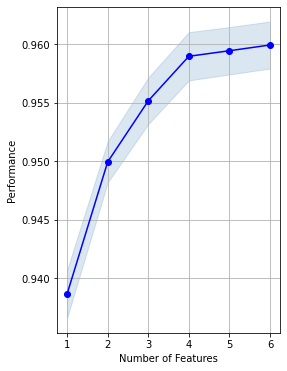

In [29]:
figure = plot_sfs(sfs_model.get_metric_dict(),kind='std_dev')
plt.grid()

In [30]:
table=table.sort_values('avg_score', ascending=False)['feature_names'].head(1)
table = table.tolist()
        
xobs_train = x_train[list(table[0][0:])]

xobs_train = sm.add_constant(xobs_train)
xobs_train.head()

C:\Users\luism\anaconda3\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)


,const,lon,lat,year,month,"(prec,)","(temp,)"
2917,1.0,-49.75,-16.75,1986,2,0.646149,-0.172297
8447,1.0,-49.50,-16.25,2004,12,1.206765,0.042770
6247,1.0,-49.50,-17.50,1991,8,-1.088802,-0.454777
12051,1.0,-49.25,-16.75,1999,4,-0.677236,-0.524095
17809,1.0,-49.00,-16.00,2003,2,0.647420,-0.512899


In [31]:
result = sm.OLS(y_train,xobs_train).fit()
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    etp   R-squared:                       0.960
Model:                            OLS   Adj. R-squared:                  0.960
Method:                 Least Squares   F-statistic:                 5.363e+04
Date:                Mon, 19 Feb 2024   Prob (F-statistic):               0.00
Time:                        14:38:01   Log-Likelihood:                -41699.
No. Observations:               13423   AIC:                         8.341e+04
Df Residuals:                   13416   BIC:                         8.347e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        515.1357     12.898     39.938      0.000     489.853     540.418
lon            5.7122      0.159     35.837      0.000       5.400       6.025
lat            0.8175      0.062     13.278      0.000       0.697       0.938
year          -0.0624      0.005    -12.881      0.000      -0.072      -0.053
month          0.5116      0.015     35.045      0.000       0.483       0.540
('prec',)      2.9430      0.050     58.985      0.000       2.845       3.041
('temp',)     25.7372      0.056    457.016      0.000      25.627      25.848
==============================================================================
Omnibus:                     4187.261   Durbin-Watson:                   1.987
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            24883.446
Skew:                           1.368   Prob(JB):                         0.00
Kurtosis:                       9.083   Cond. No.                     5.52e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 5.52e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [32]:
yest_train=result.fittedvalues
pd.DataFrame.from_dict(yest_train).to_csv('sw_train_est.csv')

In [33]:
datagraf = pd.DataFrame({'Yobs':y_train,
                         'Yest': yest_train})
datagraf.head()

,Yobs,Yest
2917,88.255314,91.759797
8447,105.929118,104.773464
6247,80.895431,82.955572
12051,80.069502,81.878273
17809,84.159994,86.833286


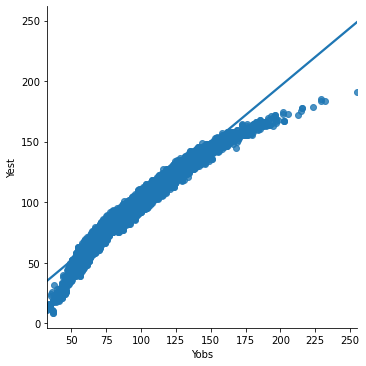

In [34]:
sns.lmplot(x='Yobs',y='Yest',data=datagraf);

In [35]:
r2 = skm.r2_score(y_train,yest_train)
mse=skm.mean_squared_error(y_train,yest_train)
rmse = mse**0.5
mae = skm.mean_absolute_error(y_train, yest_train)
rrmse = rmse*100/np.mean(y_train)
sw_mape = mape(y_train,yest_train)

r2,rmse,rrmse,sw_mape

(0.9599778948237375, 5.406620272796397, 5.536704081522298, 4.595437711710802)

## **Test**

In [36]:
xobs_test = x_test[list(table[0][0:])]
xobs_test = sm.add_constant(xobs_test)
yest_test = result.predict(xobs_test)

pd.DataFrame.from_dict(yest_test).to_csv('sw_test_est.csv')
yest_test.head()

C:\Users\luism\anaconda3\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)


15923    101.533314
16236     96.669022
3645     144.004809
13405    105.933843
2853     160.505927
dtype: float64

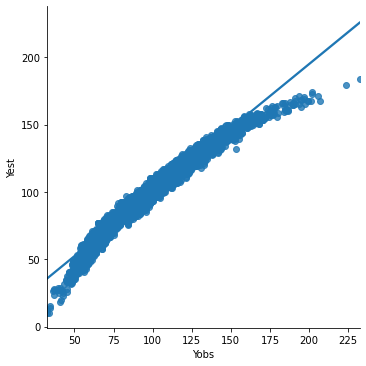

In [37]:
datagraf = pd.DataFrame({'Yobs':y_test,
                         'Yest': yest_test})
sns.lmplot(x='Yobs',y='Yest',data=datagraf);

In [38]:
r2 = skm.r2_score(y_test,yest_test)
mse=skm.mean_squared_error(y_test,yest_test)
rmse = mse**0.5
rrmse = rmse*100/np.mean(y_test)
sw_mape = mape(y_test,yest_test)

r2,rmse,rrmse,sw_mape

(0.9595863235568245, 5.48781415359446, 5.576255024068622, 4.566545105153151)

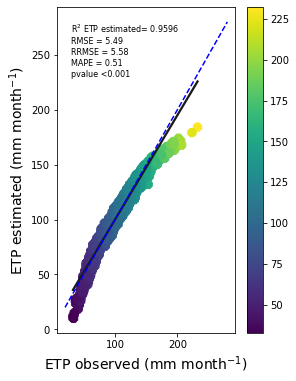

In [39]:
x=[20,280]
y=x

points = plt.scatter(y='Yest', x='Yobs',data=datagraf,
                     c=datagraf["Yobs"],marker="8", s=80, cmap="viridis") 
cbar = plt.colorbar(points, shrink=1)

sns.regplot(y='Yest', x='Yobs', data=datagraf, scatter=False, color=".1")

plt.plot(x,y, 'b--',data=None)

pvalue = 0.001
plt.text(30, 270, 'R$\mathregular{^{2}}$ ETP estimated= %0.4f' % r2,family='Segoe UI Bold',fontsize=8, color= 'black')
plt.text(30,260, 'RMSE = %0.2f'% rmse,family='Segoe UI Bold',fontsize=8)
plt.text(30,250, 'RRMSE = %0.2f'% rrmse,family='Segoe UI Bold',fontsize=8)
plt.text(30,240, 'MAPE = %0.2f'% rf_mape,family='Segoe UI Bold',fontsize=8)
plt.text(30, 230,'pvalue <%0.3f' % pvalue,family='Segoe UI Bold',fontsize=8)
plt.xlabel('ETP observed (mm month$\mathregular{^{-1}}$)',fontsize=14, family='Segoe UI Bold')
plt.ylabel('ETP estimated (mm month$\mathregular{^{-1}}$)',fontsize=14, family='Segoe UI Bold')
plt.rcParams['figure.figsize'] = (4,6)

plt.savefig('sw_teste.png', transparent = False,bbox_inches='tight', dpi=1000)

# **MLP**

In [40]:
# checando 

x_train.head(),y_train.head()

(         lon    lat  year  month   (prec,)   (temp,)
 2917  -49.75 -16.75  1986      2  0.646149 -0.172297
 8447  -49.50 -16.25  2004     12  1.206765  0.042770
 6247  -49.50 -17.50  1991      8 -1.088802 -0.454777
 12051 -49.25 -16.75  1999      4 -0.677236 -0.524095
 17809 -49.00 -16.00  2003      2  0.647420 -0.512899,
 2917      88.255314
 8447     105.929118
 6247      80.895431
 12051     80.069502
 17809     84.159994
 Name: etp, dtype: float64)

In [41]:
mlp_model= MLPRegressor().fit(x_train,y_train)

## **Random Search param**

In [42]:
max_iter = [int(x) for x in np.linspace(start = 50, stop = 2050, num = 100)]
# Maximum number of levels in tree
alpha = [float(x) for x in np.arange(0.001, .3, 0.001)]
learning_rate_init = alpha


hyperpar_space_mlp = {'hidden_layer_sizes':[(5,5),(10,10),(10,5,10),(10,10,10),
                                           (50,10,50),(50,10,5),(5,10,100)],
                          'activation':['logistic','tanh','identity'],
                          'max_iter':max_iter,
                          'learning_rate_init': learning_rate_init,
                          'solver':['adam','sgd','lbfgs'],
                          'learning_rate':['constant', 'invscaling', 'adaptive'],
                          'alpha':alpha
                         }

In [43]:
rs_mlp = RandomizedSearchCV(mlp_model, param_distributions=hyperpar_space_mlp,
                        n_iter=20, scoring="r2", random_state=1,
                        n_jobs=-1, cv=10, return_train_score=True).fit(x_train,y_train)

C:\Users\luism\anaconda3\lib\site-packages\sklearn\model_selection\_search.py:918: UserWarning: One or more of the test scores are non-finite: [-5.14467449e+02 -5.47986462e-04 -5.46619499e-04  9.55185443e-01
 -5.45106264e-04 -6.84890884e-04 -5.40828105e-04             nan
  9.54961877e-01             nan -1.04555537e-01 -1.28925757e-03
  9.54927342e-01  9.41532174e-01 -1.19289657e-03 -5.45117653e-04
 -9.77055872e-04  9.18910923e-01  1.86649066e-01  5.82476235e-02]
  warnings.warn(
C:\Users\luism\anaconda3\lib\site-packages\sklearn\model_selection\_search.py:918: UserWarning: One or more of the train scores are non-finite: [-5.14840378e+02 -4.92811052e-08 -3.28724180e-07  9.55217306e-01
 -1.04329878e-12 -3.88847812e-05  3.94108881e-07             nan
  9.54947592e-01             nan -1.03195289e-01 -5.18644296e-04
  9.54950264e-01  9.40737205e-01 -3.81248078e-04 -7.72493181e-14
 -2.03540424e-04  9.19082320e-01  1.86877255e-01  5.79704582e-02]
  warnings.warn(


In [44]:
print("Optimal hyperparameter combination:", rs_mlp.best_params_)
print()
print("Mean cross-validated training accuracy score:",
      rs_mlp.best_score_)

Optimal hyperparameter combination: {'solver': 'lbfgs', 'max_iter': 1322, 'learning_rate_init': 0.038, 'learning_rate': 'invscaling', 'hidden_layer_sizes': (10, 5, 10), 'alpha': 0.092, 'activation': 'identity'}

Mean cross-validated training accuracy score: 0.9551854432146799


In [45]:
pd.DataFrame.from_dict(rs_mlp.cv_results_).to_csv('mlp_iter.csv')
pd.DataFrame.from_dict(rs_mlp.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_solver,param_max_iter,param_learning_rate_init,param_learning_rate,param_hidden_layer_sizes,param_alpha,...,split2_train_score,split3_train_score,split4_train_score,split5_train_score,split6_train_score,split7_train_score,split8_train_score,split9_train_score,mean_train_score,std_train_score
0,34.984806,11.368389,0.006684,0.000979,sgd,555,0.138,invscaling,"(10, 5, 10)",0.204,...,-3.770874e+03,-1.231058e+00,-4.812546e+00,-1.625502e+00,-1.202658e+03,-3.184400e+00,-4.486639e-01,-1.303914e-01,-5.148404e+02,1.141965e+03
1,8.251587,1.160632,0.005281,0.000461,sgd,1140,0.143,adaptive,"(10, 10)",0.001,...,-9.106351e-10,-7.966570e-08,-4.570210e-08,-1.112305e-08,-3.144014e-07,-2.302127e-10,-1.184465e-08,-1.402508e-08,-4.928111e-08,9.146712e-08
2,7.067950,0.262832,0.006858,0.001235,sgd,130,0.236,adaptive,"(5, 5)",0.293,...,-9.723055e-07,-1.889418e-07,-6.439381e-08,-9.886274e-07,-2.226665e-07,-1.369874e-07,-7.061342e-07,-2.645805e-09,-3.287242e-07,3.806575e-07
3,8.605583,4.882947,0.005687,0.000703,lbfgs,1322,0.038,invscaling,"(10, 5, 10)",0.092,...,9.554610e-01,9.554391e-01,9.550915e-01,9.550405e-01,9.548031e-01,9.549885e-01,9.554484e-01,9.556075e-01,9.552173e-01,2.457586e-04
4,1.191265,0.276012,0.014006,0.003508,lbfgs,433,0.266,constant,"(50, 10, 50)",0.036,...,-1.310285e-12,-7.263079e-13,-1.763034e-13,-1.811884e-13,-2.715606e-13,-3.352874e-14,-8.240075e-13,-6.159739e-12,-1.043299e-12,1.746653e-12
5,2.015940,0.378678,0.006975,0.000447,adam,938,0.086,constant,"(10, 5, 10)",0.24,...,-1.292411e-05,-5.398847e-05,-5.042771e-05,-1.605541e-05,-1.816858e-04,-1.300612e-05,-8.507036e-06,-1.909523e-05,-3.888478e-05,5.003581e-05
6,0.508905,0.783572,0.006434,0.000787,lbfgs,1706,0.092,adaptive,"(10, 10, 10)",0.211,...,-3.783993e-10,-2.049960e-10,-3.179501e-11,-1.476552e-11,3.942775e-06,-1.470206e-10,-7.158425e-10,-1.142220e-11,3.941089e-07,1.182889e-06
7,17.608916,0.652722,0.025095,0.006431,sgd,151,0.124,adaptive,"(50, 10, 50)",0.126,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,6.822713,3.956258,0.005983,0.001092,lbfgs,999,0.22,constant,"(10, 10, 10)",0.287,...,9.553968e-01,9.551644e-01,9.549738e-01,9.549198e-01,9.548928e-01,9.551037e-01,9.554353e-01,9.531523e-01,9.549476e-01,6.233306e-04
9,11.534925,0.430097,0.017564,0.008799,sgd,130,0.286,constant,"(5, 10, 100)",0.19,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


(-1.0, 1.0)

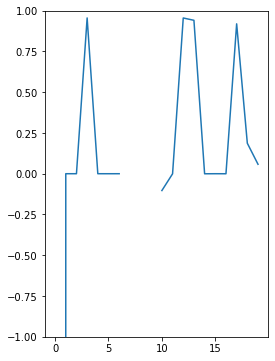

In [46]:
pd.DataFrame.from_dict(rs_mlp.cv_results_)['mean_train_score'].plot()
plt.ylim(-1,1)

## **Train**

In [47]:
yest_train = rs_mlp.best_estimator_.predict(x_train)
pd.DataFrame.from_dict(yest_train).to_csv('mlp_train_est.csv')

In [48]:
datagraf = pd.DataFrame({'Yobs':y_train,
                         'Yest': yest_train})
datagraf.head()

,Yobs,Yest
2917,88.255314,91.697255
8447,105.929118,107.192008
6247,80.895431,82.778065
12051,80.069502,81.570052
17809,84.159994,86.279571


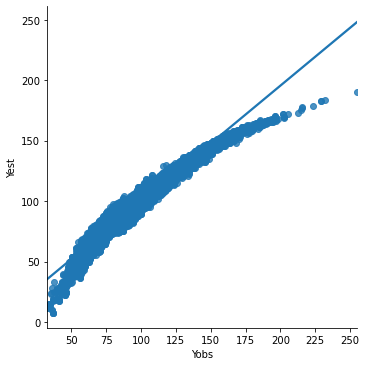

In [49]:
sns.lmplot(x='Yobs',y='Yest',data=datagraf);

In [50]:
r2 = skm.r2_score(y_train,yest_train)
mse=skm.mean_squared_error(y_train,yest_train)
rmse = mse**0.5
mae = skm.mean_absolute_error(y_train,yest_train)
rrmse = rmse*100/np.mean(y_train)
ann_mape = mape(y_train,yest_train)

r2,rmse,rrmse,ann_mape

(0.9551466046235796, 5.723656555337822, 5.861368287804695, 4.9391660378894215)

## **Test**

In [51]:
x_test.head(),y_test.head()

(         lon   lat  year  month   (prec,)   (temp,)
 15923 -49.00 -17.0  1981     12  1.573126 -0.267958
 16236 -49.00 -17.0  2008      1  0.667208 -0.069233
 3645  -49.75 -16.5  2012     10 -0.511302  1.886117
 13405 -49.25 -16.0  2010      2  0.508990  0.317533
 2853  -49.75 -17.0  2014     10 -0.651456  2.564015,
 15923    103.036736
 16236    103.541886
 3645     155.410013
 13405    100.205722
 2853     185.456329
 Name: etp, dtype: float64)

In [52]:
yest_test = rs_mlp.best_estimator_.predict(x_test)
pd.DataFrame.from_dict(yest_test).to_csv('mlp_test_est.csv')


In [53]:
datagraf = pd.DataFrame({'Yobs':y_test,
                         'Yest': yest_test})
datagraf.head()

,Yobs,Yest
15923,103.036736,98.913502
16236,103.541886,96.670874
3645,155.410013,146.331482
13405,100.205722,106.762323
2853,185.456329,162.634937


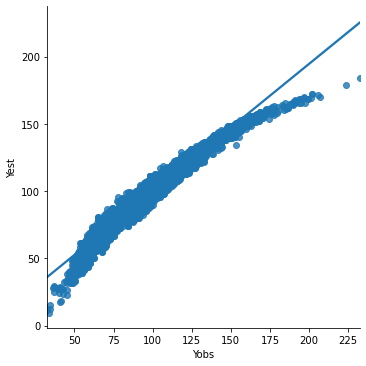

In [54]:
sns.lmplot(x='Yobs',y='Yest',data=datagraf);

In [55]:
r2 = skm.r2_score(y_test,yest_test)
mse=skm.mean_squared_error(y_test,yest_test)
rmse = mse**0.5
rrmse = rmse*100/np.mean(y_test)
ann_mape = mape(y_test,yest_test)

r2,rmse,rrmse,ann_mape

(0.9550922291334897, 5.784901444463392, 5.878130133525406, 4.919008432850576)

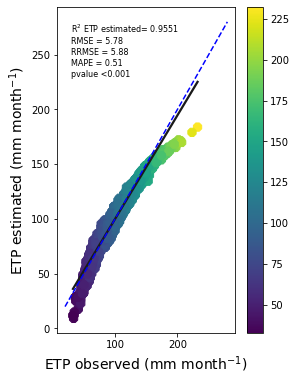

In [56]:
x=[20,280]
y=x

points = plt.scatter(y='Yest', x='Yobs',data=datagraf,
                     c=datagraf["Yobs"],marker="8", s=80, cmap="viridis") 
cbar = plt.colorbar(points, shrink=1)

sns.regplot(y='Yest', x='Yobs', data=datagraf, scatter=False, color=".1")

plt.plot(x,y, 'b--',data=None)

pvalue = 0.001
plt.text(30, 270, 'R$\mathregular{^{2}}$ ETP estimated= %0.4f' % r2,family='Segoe UI Bold',fontsize=8, color= 'black')
plt.text(30,260, 'RMSE = %0.2f'% rmse,family='Segoe UI Bold',fontsize=8)
plt.text(30,250, 'RRMSE = %0.2f'% rrmse,family='Segoe UI Bold',fontsize=8)
plt.text(30,240, 'MAPE = %0.2f'% rf_mape,family='Segoe UI Bold',fontsize=8)
plt.text(30, 230,'pvalue <%0.3f' % pvalue,family='Segoe UI Bold',fontsize=8)
plt.xlabel('ETP observed (mm month$\mathregular{^{-1}}$)',fontsize=14, family='Segoe UI Bold')
plt.ylabel('ETP estimated (mm month$\mathregular{^{-1}}$)',fontsize=14, family='Segoe UI Bold')
plt.rcParams['figure.figsize'] = (4,6)

plt.savefig('ann_teste.png', transparent = False,bbox_inches='tight', dpi=1000)

# **General Forecasting**

In [57]:
yest_validation = rs_rf.best_estimator_.predict(x_validation)

In [58]:
datagraf = pd.DataFrame({'Yobs':y_validation,
                         'Yest': yest_validation})
datagraf.head()

,Yobs,Yest
0,154.050025,132.080217
1,113.652797,104.533858
2,110.835384,103.471126
3,105.644868,95.391611
4,72.644352,68.925077


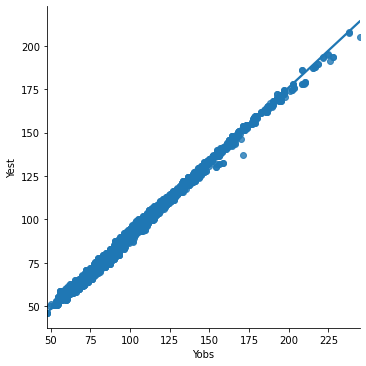

In [59]:
sns.lmplot(x='Yobs',y='Yest',data=datagraf);

In [60]:
r2 = skm.r2_score(y_validation,yest_validation)
mse=skm.mean_squared_error(y_validation,yest_validation)
rmse = mse**0.5
mae = skm.mean_absolute_error(y_validation, yest_validation)
rrmse = rmse*100/np.mean(y_validation)
rf_mape = mape(y_validation,yest_validation)



r2,rmse,rrmse, rf_mape

(0.8697587381373312, 11.45303132441915, 10.622974348404075, 9.092505043056466)

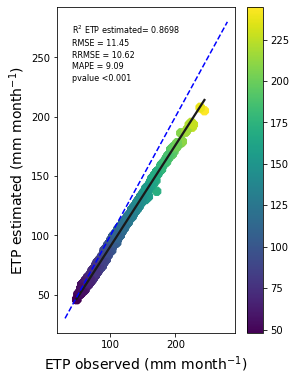

In [61]:
x=[30,280]
y=x

points = plt.scatter(y='Yest', x='Yobs',data=datagraf,
                     c=datagraf["Yobs"],marker="8", s=80, cmap="viridis") 
cbar = plt.colorbar(points, shrink=1)

sns.regplot(y='Yest', x='Yobs', data=datagraf, scatter=False, color=".1")

plt.plot(x,y, 'b--',data=None)

pvalue = 0.001
plt.text(40, 270, 'R$\mathregular{^{2}}$ ETP forecasted= %0.4f' % r2,family='Segoe UI Bold',fontsize=8, color= 'black')
plt.text(40,260, 'RMSE = %0.2f'% rmse,family='Segoe UI Bold',fontsize=8)
plt.text(40,250, 'RRMSE = %0.2f'% rrmse,family='Segoe UI Bold',fontsize=8)
plt.text(40,240, 'MAPE = %0.2f'% rf_mape,family='Segoe UI Bold',fontsize=8)
plt.text(40, 230,'pvalue <%0.3f' % pvalue,family='Segoe UI Bold',fontsize=8)
plt.xlabel('ETP observed (mm month$\mathregular{^{-1}}$)',fontsize=14, family='Segoe UI Bold')
plt.ylabel('ETP forecasted (mm month$\mathregular{^{-1}}$)',fontsize=14, family='Segoe UI Bold')
plt.rcParams['figure.figsize'] = (4,6)

plt.savefig('rf_validation.png', transparent = False,bbox_inches='tight', dpi=1000)

In [62]:
prec = data_validation['prec']
datagraf['prec']=prec
datagraf['et_obs']=datagraf['Yobs']
datagraf['et_est']=datagraf['Yest']
datagraf['year']=data_validation['year']
datagraf['month']=data_validation['month']

datagraf.to_csv('est_validiation.csv')

In [63]:
df15 = x_validation[(x_validation['year']==2015)]
df16= x_validation[(x_validation['year']==2016)]
df17= x_validation[(x_validation['year']==2017)]
df18= x_validation[(x_validation['year']==2018)]
df19= x_validation[(x_validation['year']==2019)]
df20= x_validation[(x_validation['year']==2020)]
df21= x_validation[(x_validation['year']==2021)]

In [64]:
y_15=y_validation[y_validation.index.isin(df15.index)]
y_16=y_validation[y_validation.index.isin(df16.index)]
y_17=y_validation[y_validation.index.isin(df17.index)]
y_18=y_validation[y_validation.index.isin(df18.index)]
y_19=y_validation[y_validation.index.isin(df19.index)]
y_20=y_validation[y_validation.index.isin(df20.index)]
y_21=y_validation[y_validation.index.isin(df21.index)]

In [65]:
yest_15 =rs_rf.best_estimator_.predict(df15)
datagraf = pd.DataFrame({'Yobs':y_15,
                         'Yest': yest_15})
r2 = skm.r2_score(y_15,yest_15)
mse=skm.mean_squared_error(y_15,yest_15)
rmse = mse**0.5
mae = skm.mean_absolute_error(y_15, yest_15)
rrmse = rmse*100/np.mean(y_15)
rf_mape = mape(y_15,yest_15)



r2,rmse,rrmse, rf_mape

(0.9015259609276676, 12.274228862887457, 11.05879724284656, 8.560433032648179)

In [66]:
yest_16 =rs_rf.best_estimator_.predict(df16)
datagraf = pd.DataFrame({'Yobs':y_16,
                         'Yest': yest_16})
r2 = skm.r2_score(y_16,yest_16)
mse=skm.mean_squared_error(y_16,yest_16)
rmse = mse**0.5
mae = skm.mean_absolute_error(y_16, yest_16)
rrmse = rmse*100/np.mean(y_16)
rf_mape = mape(y_16,yest_16)



r2,rmse,rrmse, rf_mape

(0.7816980147429231, 11.127685435123293, 10.278810831237747, 9.697290331726869)

In [67]:
yest_17 =rs_rf.best_estimator_.predict(df17)
datagraf = pd.DataFrame({'Yobs':y_17,
                         'Yest': yest_17})
r2 = skm.r2_score(y_17,yest_17)
mse=skm.mean_squared_error(y_17,yest_17)
rmse = mse**0.5
mae = skm.mean_absolute_error(y_17, yest_17)
rrmse = rmse*100/np.mean(y_17)
rf_mape = mape(y_17,yest_17)



r2,rmse,rrmse, rf_mape

(0.8638247286963258, 10.725951354283781, 10.204263518643888, 9.128917610530769)

In [68]:
yest_18 =rs_rf.best_estimator_.predict(df18)
datagraf = pd.DataFrame({'Yobs':y_18,
                         'Yest': yest_18})
r2 = skm.r2_score(y_18,yest_18)
mse=skm.mean_squared_error(y_18,yest_18)
rmse = mse**0.5
mae = skm.mean_absolute_error(y_18, yest_18)
rrmse = rmse*100/np.mean(y_18)
rf_mape = mape(y_18,yest_18)



r2,rmse,rrmse, rf_mape

(0.7948695716738026, 10.377573792510386, 10.259156457369167, 9.416565309812269)

In [69]:
yest_19 =rs_rf.best_estimator_.predict(df19)

datagraf = pd.DataFrame({'Yobs':y_19,
                         'Yest': yest_19})
r2 = skm.r2_score(y_19,yest_19)
mse=skm.mean_squared_error(y_19,yest_19)
rmse = mse**0.5
mae = skm.mean_absolute_error(y_19, yest_19)
rrmse = rmse*100/np.mean(y_19)
rf_mape = mape(y_19,yest_19)



r2,rmse,rrmse, rf_mape

(0.8817606906216304, 12.004891573520736, 10.698659966081623, 8.802044618698485)

In [70]:
yest_20 =rs_rf.best_estimator_.predict(df20)

datagraf = pd.DataFrame({'Yobs':y_20,
                         'Yest': yest_20})
r2 = skm.r2_score(y_20,yest_20)
mse=skm.mean_squared_error(y_20,yest_20)
rmse = mse**0.5
mae = skm.mean_absolute_error(y_20, yest_20)
rrmse = rmse*100/np.mean(y_20)
rf_mape = mape(y_20,yest_20)



r2,rmse,rrmse, rf_mape

(0.8944184233701635, 11.688102829093955, 10.797262101096903, 8.697957883140559)

In [71]:
yest_21 =rs_rf.best_estimator_.predict(df21)
datagraf = pd.DataFrame({'Yobs':y_21,
                         'Yest': yest_21})
r2 = skm.r2_score(y_21,yest_21)
mse=skm.mean_squared_error(y_21,yest_21)
rmse = mse**0.5
mae = skm.mean_absolute_error(y_21, yest_21)
rrmse = rmse*100/np.mean(y_21)
rf_mape = mape(y_21,yest_21)



r2,rmse,rrmse, rf_mape

(0.8580465774636186, 11.842810840183413, 10.892867265147833, 9.344326514838238)

# **stat**

In [72]:
from scipy import stats
import numpy as np
import pandas as pd
import sklearn.metrics as skm
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor as rfs
from sklearn.neural_network import MLPRegressor 
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression 
from mlxtend.feature_selection import SequentialFeatureSelector as sfs
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RandomizedSearchCV
from mlxtend.plotting import plot_sequential_feature_selection as plot_sfs

In [73]:
data = pd.read_csv('tab_training.csv')
data[['etp']].describe().T

,count,mean,std,min,25%,50%,75%,max
etp,19176.0,97.879563,27.110682,32.710081,78.223811,98.051897,113.817242,254.938349


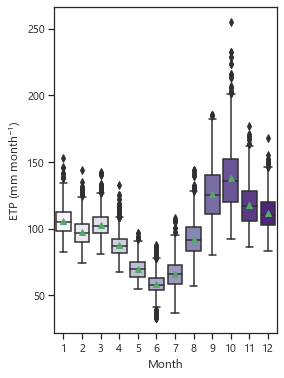

In [74]:
x = data[['etp','month']]
sns.set(style="ticks",font='Segoe UI', color_codes= True)
sns.boxplot(palette='Purples',data=x, x= 'month',y='etp' ,showmeans=True)
plt.rcParams['figure.figsize'] = (7,6)  #largura x altura
plt.xlabel('Month',fontsize=12, family='Segoe UI')
plt.ylabel('ETP (mm month$\mathregular{^{-1}}$)',fontsize=12, family='Segoe UI')
#plt.legend(['means'],loc=)
plt.savefig('etpanos.png', transparent = False,bbox_inches='tight', dpi=1000)
plt.show()

In [75]:
data[['prec']].describe().T

,count,mean,std,min,25%,50%,75%,max
prec,19176.0,121.237343,110.167366,0.0,18.6,97.165,202.8425,661.95


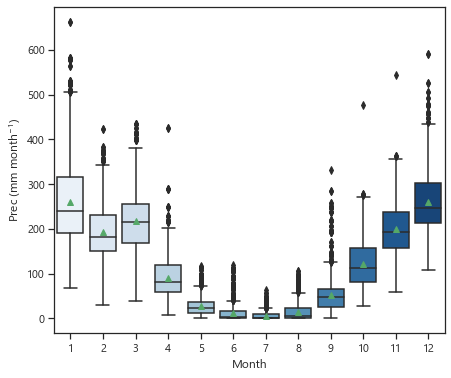

In [76]:
x = data[['prec','month']]
sns.set(style="ticks",font='Segoe UI', color_codes= True)
sns.boxplot(palette='Blues',data=x, x= 'month',y='prec' ,showmeans=True)
plt.rcParams['figure.figsize'] = (7,6)  #largura x altura
plt.xlabel('Month',fontsize=12, family='Segoe UI')
plt.ylabel('Prec (mm month$\mathregular{^{-1}}$)',fontsize=12, family='Segoe UI')
#plt.legend(['means'],loc=)
plt.savefig('prec.png', transparent = False,bbox_inches='tight', dpi=1000)
plt.show()

In [77]:
data[['temp']].describe().T

,count,mean,std,min,25%,50%,75%,max
temp,19176.0,23.1342,2.194697,15.539667,21.71075,23.192857,24.485809,31.380645


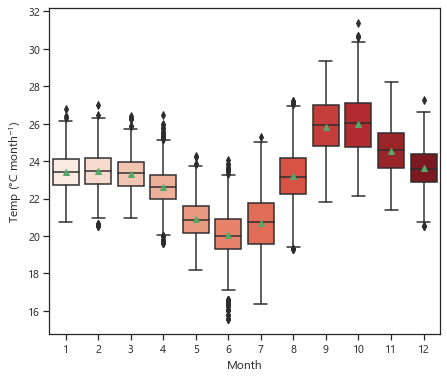

In [78]:
x = data[['temp','month']]
sns.set(style="ticks",font='Segoe UI', color_codes= True)
sns.boxplot(palette='Reds',data=x, x= 'month',y='temp' ,showmeans=True)
plt.rcParams['figure.figsize'] = (7,6)  #largura x altura
plt.xlabel('Month',fontsize=12, family='Segoe UI')
plt.ylabel('Temp (°C month$\mathregular{^{-1}}$)',fontsize=12, family='Segoe UI')
#plt.legend(['means'],loc=)
plt.savefig('temp.png', transparent = False,bbox_inches='tight', dpi=1000)
plt.show()

In [79]:
data.groupby('month')[['etp']].describe()

etp                                                            \
        count        mean        std        min         25%         50%   
month                                                                     
1      1598.0  105.901764  10.670164  82.633105   98.249818  105.051381   
2      1598.0   97.654487  10.351627  74.251693   90.278265   96.818283   
3      1598.0  102.863400   9.509960  81.312171   96.412209  102.381362   
4      1598.0   87.603701   9.056136  67.544708   81.664975   86.843134   
5      1598.0   69.755997   7.424557  54.799326   63.875787   69.505334   
6      1598.0   58.765551   8.118335  32.710081   53.767749   57.857933   
7      1598.0   65.976114  11.273576  36.872165   58.198652   66.107630   
8      1598.0   92.546010  14.035202  57.331063   83.232721   91.548742   
9      1598.0  125.930360  20.653820  80.050068  111.023270  124.965386   
10     1598.0  137.867960  24.322016  92.125683  119.667202  135.825825   
11     1598.0  117.843181  15.924633  86.016818  105.629719  116.859058   
12     1598.0  111.846235  13.001478  83.521793  102.611691  110.413296   

                               
              75%         max  
month                          
1      112.823571  153.138131  
2      103.703759  143.915836  
3      108.650587  142.735328  
4       92.382264  132.957776  
5       75.200142   97.115095  
6       63.333714   88.042920  
7       72.945491  108.285901  
8      101.206081  143.840108  
9      140.366718  185.478932  
10     152.320512  254.938349  
11     128.390455  176.920646  
12     119.966655  168.165427

In [80]:
data.groupby('month')[['prec']].describe()

prec                                                              \
        count        mean         std     min      25%      50%       75%   
month                                                                       
1      1598.0  260.243642  101.382261   68.23  190.645  239.530  316.7500   
2      1598.0  193.063836   66.215282   31.14  150.480  181.955  230.7600   
3      1598.0  216.943191   70.570075   38.48  167.610  214.735  255.7300   
4      1598.0   90.339962   44.286140    7.87   58.960   80.780  119.8900   
5      1598.0   28.494168   23.056143    0.29   12.030   22.595   36.4475   
6      1598.0   11.381320   17.351670    0.00    0.460    4.070   16.0600   
7      1598.0    6.113304    8.960799    0.00    0.110    1.605    9.1650   
8      1598.0   14.424543   19.964838    0.00    0.240    4.870   23.5350   
9      1598.0   52.394418   40.616254    0.19   26.645   48.460   66.5900   
10     1598.0  122.381696   51.993887   28.82   81.935  112.930  157.4400   
11     1598.0  199.521902   57.754059   60.02  156.550  192.490  236.9100   
12     1598.0  259.546133   71.595566  107.91  212.490  246.705  302.0200   

               
          max  
month          
1      661.95  
2      422.24  
3      434.44  
4      426.08  
5      117.31  
6      118.89  
7       62.49  
8      105.12  
9      330.79  
10     476.23  
11     542.46  
12     589.58

In [81]:
data.groupby('month')[['temp']].describe()

temp                                                        \
        count       mean       std        min        25%        50%   
month                                                                 
1      1598.0  23.408291  1.013709  20.769355  22.720323  23.410323   
2      1598.0  23.464840  1.050597  20.534483  22.767857  23.498214   
3      1598.0  23.324268  0.956773  20.946129  22.664194  23.380645   
4      1598.0  22.609929  1.045606  19.618000  21.966333  22.630667   
5      1598.0  20.896786  1.040952  18.172258  20.163871  20.874355   
6      1598.0  20.065927  1.299186  15.539667  19.296333  20.023000   
7      1598.0  20.679396  1.553878  16.346129  19.563387  20.731452   
8      1598.0  23.194399  1.427986  19.303871  22.259274  23.144516   
9      1598.0  25.840215  1.552476  21.819333  24.781333  25.928333   
10     1598.0  25.963179  1.624511  22.122581  24.775806  26.010645   
11     1598.0  24.547289  1.283745  21.391667  23.621667  24.599167   
12     1598.0  23.615885  1.116719  20.549032  22.864516  23.576129   

                             
             75%        max  
month                        
1      24.105806  26.780323  
2      24.184483  26.991429  
3      23.956774  26.419032  
4      23.246667  26.474333  
5      21.616452  24.289677  
6      20.897667  24.054333  
7      21.770000  25.271290  
8      24.151532  27.186452  
9      27.020333  29.357333  
10     27.105968  31.380645  
11     25.479333  28.247333  
12     24.376694  27.279677

In [82]:
data = pd.read_csv('climatology.csv')
data

,Unnamed: 0,station,month,prec,temp,etp,etr,def,exc,wb
0,1,-49.75_-18.5,1,247.178235,25.205636,126.586451,126.586451,0.000000,120.591784,120.591784
1,2,-49.75_-18.5,2,182.515294,25.211900,115.821529,115.821529,0.000000,66.693765,66.693765
2,3,-49.75_-18.5,3,189.531176,24.937647,119.634854,119.634854,0.000000,69.896323,69.896323
3,4,-49.75_-18.5,4,75.514412,24.238490,100.957680,97.978787,2.978893,0.000000,-2.978893
4,5,-49.75_-18.5,5,31.600588,22.426262,77.800730,60.287106,17.513624,0.000000,-17.513624
...,...,...,...,...,...,...,...,...,...,...
559,560,-48.75_-16.25,8,13.918235,22.491594,87.833634,25.706335,62.127298,0.000000,-62.127298
560,561,-48.75_-16.25,9,51.826176,24.805667,112.593843,56.732326,55.861517,0.000000,-55.861517
561,562,-48.75_-16.25,10,142.413824,24.439734,116.570142,116.570142,0.000000,0.000000,0.000000
562,563,-48.75_-16.25,11,217.626765,22.807784,98.422851,98.422851,0.000000,50.915069,50.915069


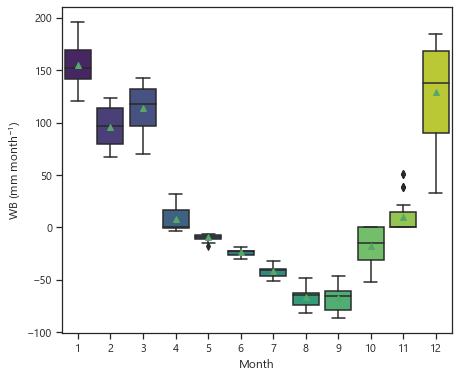

In [83]:
x = data[['wb','month']]
sns.set(style="ticks",font='Segoe UI', color_codes= True)
sns.boxplot(palette='viridis',data=x, x= 'month',y='wb' ,showmeans=True)
plt.rcParams['figure.figsize'] = (7,6)  #largura x altura
plt.xlabel('Month',fontsize=12, family='Segoe UI')
plt.ylabel('WB (mm month$\mathregular{^{-1}}$)',fontsize=12, family='Segoe UI')
#plt.legend(['means'],loc=)
plt.savefig('wdanos.png', transparent = False,bbox_inches='tight', dpi=1000)
plt.show()